<a href="https://colab.research.google.com/github/zeinab29/Encrption_using_play_fair/blob/main/COVID_CT_VGG19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"zeinabsalem","key":"82e8de1cc490a84066a7e3f4d63f0986"}'}

In [3]:
!mkdir ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [4]:
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d plameneduardo/sarscov2-ctscan-dataset

Dataset URL: https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset
License(s): CC-BY-NC-SA-4.0
sarscov2-ctscan-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
from zipfile import ZipFile
file_name = "sarscov2-ctscan-dataset.zip"
with ZipFile(file_name , 'r')as zip:
  zip.extractall()
  print('done')

done


In [7]:
!pip install split-folders
import splitfolders as sf

In [8]:
input_folder = "/content/dataset"
output = "/content/splited"

In [9]:
sf.ratio(input_folder, output="output", seed=42, ratio=(.7, .2,.1))

Copying files: 2481 files [00:01, 2308.94 files/s]


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    shear_range=0.2,
brightness_range=[0.8,1.2],
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:

train_path = "/content/output/train"
val_path = "/content/output/val"
test_path = "/content/output/test"

train_data = train_datagen.flow_from_directory(train_path, target_size=(224, 224), batch_size=32)
val_data = val_test_datagen.flow_from_directory(val_path, target_size=(224, 224), batch_size=32)
test_data = val_test_datagen.flow_from_directory(test_path, target_size=(224, 224), batch_size=32, shuffle=False)


Found 1984 images belonging to 2 classes.
Found 495 images belonging to 2 classes.
Found 498 images belonging to 2 classes.


In [13]:
import keras
import keras.utils
from keras import utils as np_utils
from keras.applications.vgg19 import VGG19
from keras.layers import Dropout
vgg19 = keras.applications.vgg19
conv_model = vgg19.VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [15]:
for layer in conv_model.layers:
    layer.trainable = True

In [16]:
x = keras.layers.Flatten()(conv_model.output)
x = keras.layers.Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
x = keras.layers.Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = keras.layers.Dense(2, activation='softmax')(x)
full_model = keras.models.Model(inputs=conv_model.input, outputs=predictions)
full_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             

 Total params: 139,578,434 (532.45 MB)

 Trainable params: 139,578,434 (532.45 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
full_model.compile(loss='categorical_crossentropy',
                  optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  metrics=['accuracy'])

In [20]:
from keras.callbacks import EarlyStopping

early = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=10, verbose=1, mode='auto',restore_best_weights=True)

history = full_model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    #steps_per_epoch=5,
    validation_data = val_data,
    validation_steps=len(val_data),
    epochs=50,
    callbacks=[early])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6095 - loss: 0.7444 - val_accuracy: 0.8505 - val_loss: 0.3637
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 52s 827ms/step - accuracy: 0.7693 - loss: 0.4747 - val_accuracy: 0.8727 - val_loss: 0.3460
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 81s 815ms/step - accuracy: 0.8509 - loss: 0.3711 - val_accuracy: 0.8667 - val_loss: 0.3359
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 52s 834ms/step - accuracy: 0.8625 - loss: 0.3284 - val_accuracy: 0.8747 - val_loss: 0.3036
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 81s 825ms/step - accuracy: 0.8957 - loss: 0.2706 - val_accuracy: 0.9030 - val_loss: 0.2500
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 82s 816ms/step - accuracy: 0.8842 - loss: 0.3000 - val_accuracy: 0.9172 - val_loss: 0.2197
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 82s 818ms/step - accuracy: 0.9095 - loss: 0.2281 - val_accuracy: 0.9071 - val_loss: 0.2330
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 82s 813ms/step - accuracy: 0.9135 - loss: 0.2142 - val_accura

Text(0.5, 0, 'epoch')

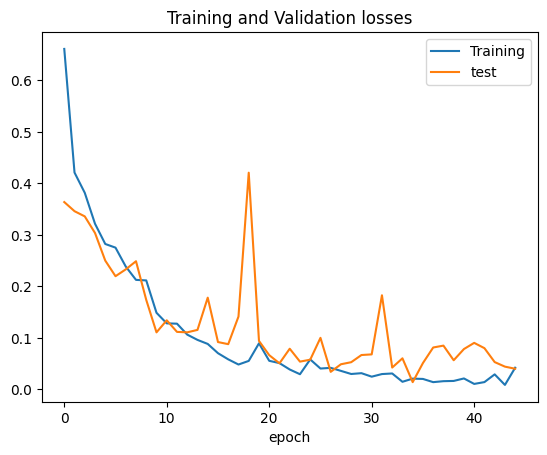

In [21]:
history.history.keys()
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'test'])
plt.title('Training and Validation losses')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

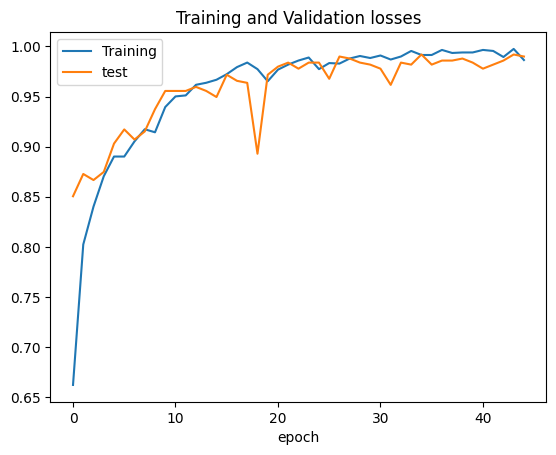

In [22]:
history.history.keys()
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'test'])
plt.title('Training and Validation losses')
plt.xlabel('epoch')

In [23]:
import numpy as np
preds = full_model.predict(test_data)
y_pred = np.argmax(preds, axis=1)
print(y_pred)

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 696ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1

              precision    recall  f1-score   support

       COVID       0.98      1.00      0.99       251
   non-COVID       1.00      0.98      0.99       247

    accuracy                           0.99       498
   macro avg       0.99      0.99      0.99       498
weighted avg       0.99      0.99      0.99       498



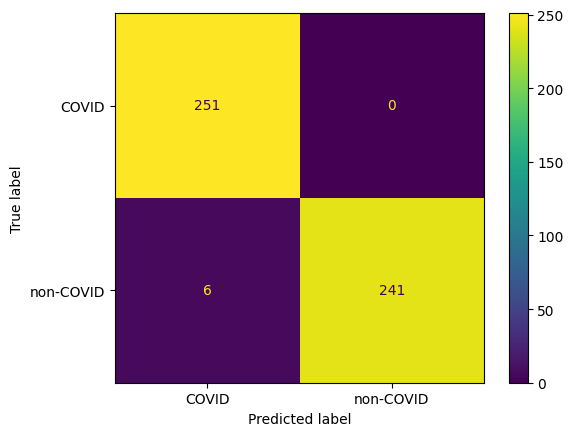

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

g_dict = test_data.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
# Classification report
print(classification_report(test_data.classes, y_pred, target_names= classes))